# Deep Learning
## 11/18/2025

<a href="?print-pdf">print view</a>

<a href="./deeplearning.ipynb">notebook</a>

# Perceptron

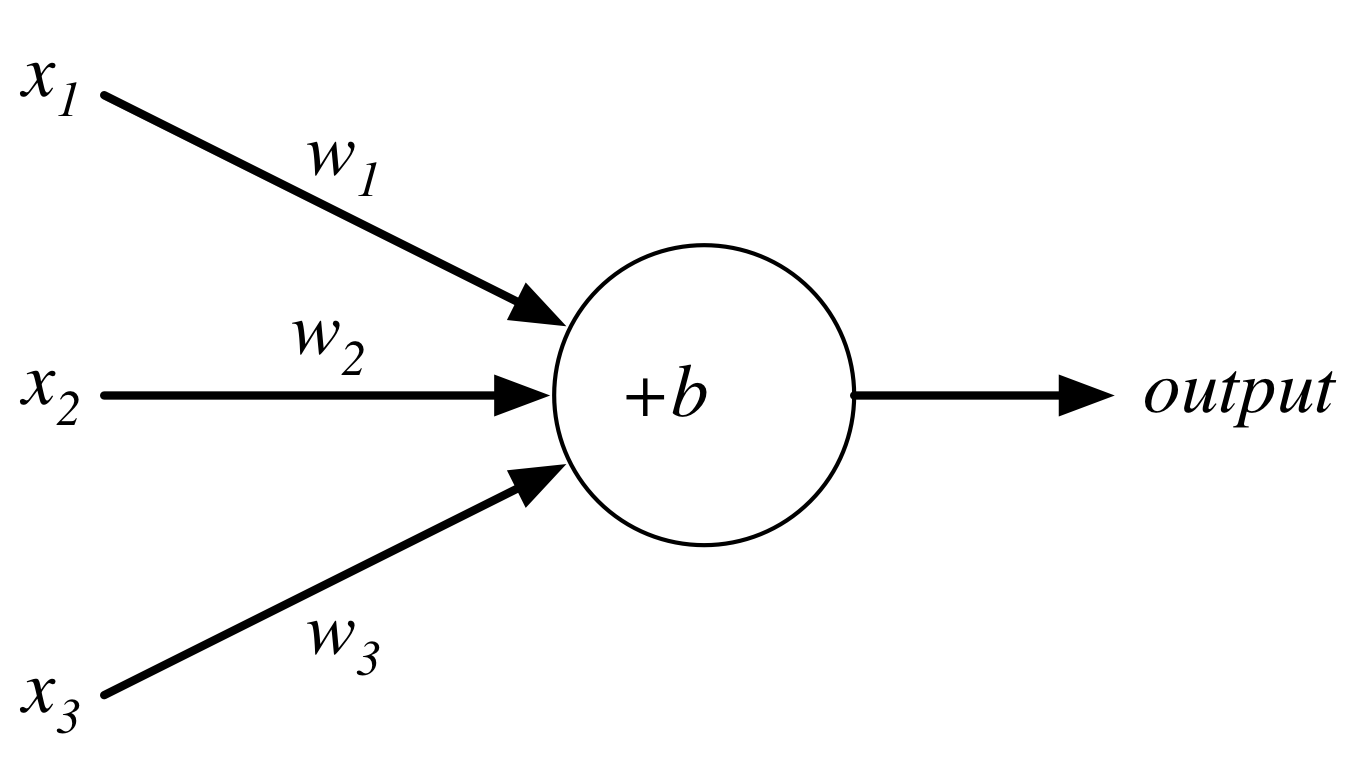

$$output = \begin{cases} 0 \text{ if } w\cdot x + b \le 0 \\ 1 \text{ if } w\cdot x + b > 0 \end{cases}$$

# Perceptron

Consider the following perceptron:

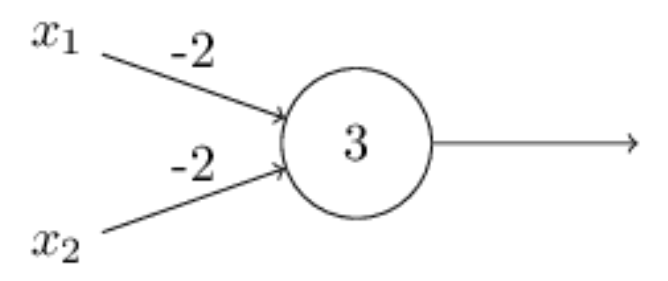

If $x$ takes on only binary values, what are the possible outputs?


### **question**: "What are the corresponding outputs for x = [0,0],[0,1],[1,0], and [1,1]?",
- 0,0,0,0,
- 0,1,1,0
- 0,0,0,1
- 0,1,1,1
- 1,1,1,0

    


# Neurons

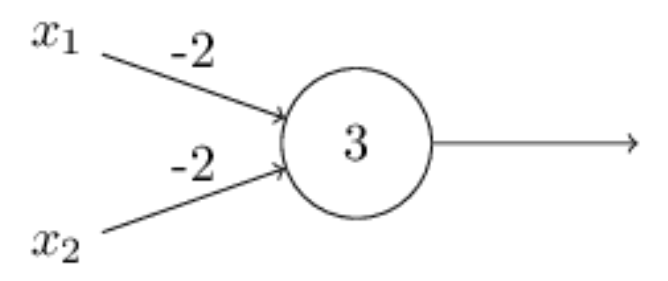

Instead of a *binary* output, we set the output to the result of an **activation function** $\sigma$

$$output = \sigma(w\cdot x + b)$$

# Activation Functions: Step (Perceptron)

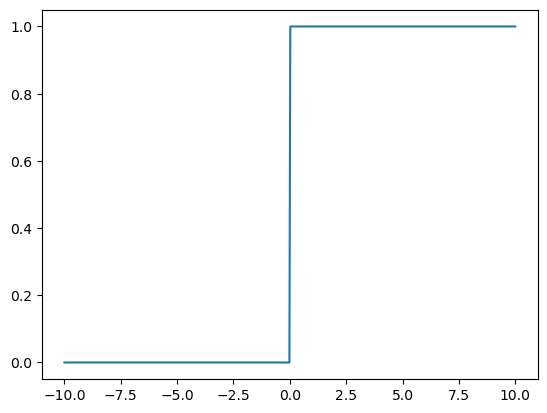

In [3]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(-10,10,500)
plt.plot(x,np.heaviside(x,0))
plt.show()

# Activation Functions: Sigmoid (Logistic)

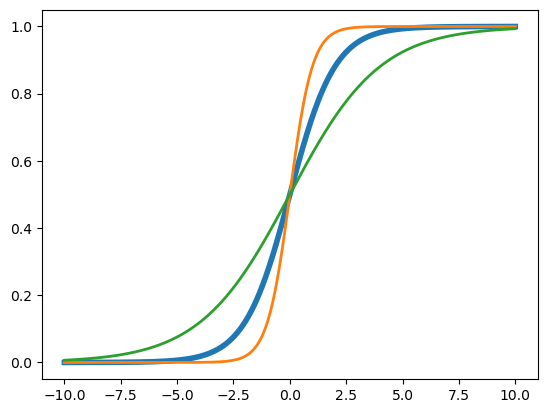

In [4]:
plt.plot(x, 1/(1+np.exp(-x)),linewidth=4);
plt.plot(x, 1/(1+np.exp(-2*x)),linewidth=2);
plt.plot(x, 1/(1+np.exp(-.5*x)),linewidth=2);
plt.show()

# Activation Functions: tanh

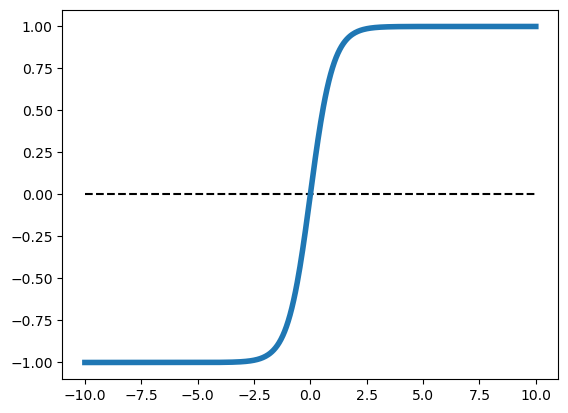

In [5]:
plt.plot([-10,10],[0,0],'k--')
plt.plot(x, np.tanh(x),linewidth=4);
plt.show()

# Activation Functions: ReLU
Rectified Linear Unit: $\sigma(z) = \max(0,z)$

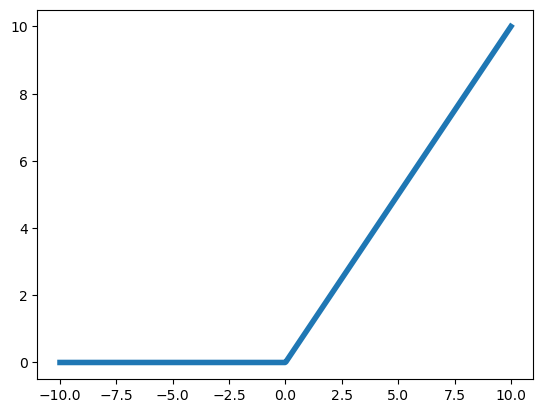

In [6]:
plt.plot(x,x*(x > 0),linewidth=4);
plt.show()

# Neural Networks

<img src="../files/networks.png">

Networks of neurons are sometimes called *multilayer perceptrons*, despite not using the step function.

### **question**: "A network has 10 input nodes, two hidden layers each with 10 neurons, and 10 output neurons.  How many parameters does training have to estimate?",
- 30
- 100
- 300
- 330
- 600

# Neural Networks

The number of input neurons corresponds to the number of features.

The number of output neurons corresponds to the number of label classes.  For binary classification, it is common to have one output node.

Layers are typically *fully connected*.

# Neural Networks

The <a href="https://en.wikipedia.org/wiki/Universal_approximation_theorem">universal approximation theorem</a> says that, if some reasonable assumptions are made, a feedforward neural network with a finite number of nodes can approximate any continuous function to within a given error $\epsilon$ over a bounded input domain.

The theorem says nothing about the design (number of nodes/layers) of such a network.

The theorem says nothing about the *learnability* of the weights of such a network.

These are open theoretical questions.

Given a network design, how are we going to learn weights for the neurons?

# Stochastic Gradient Descent
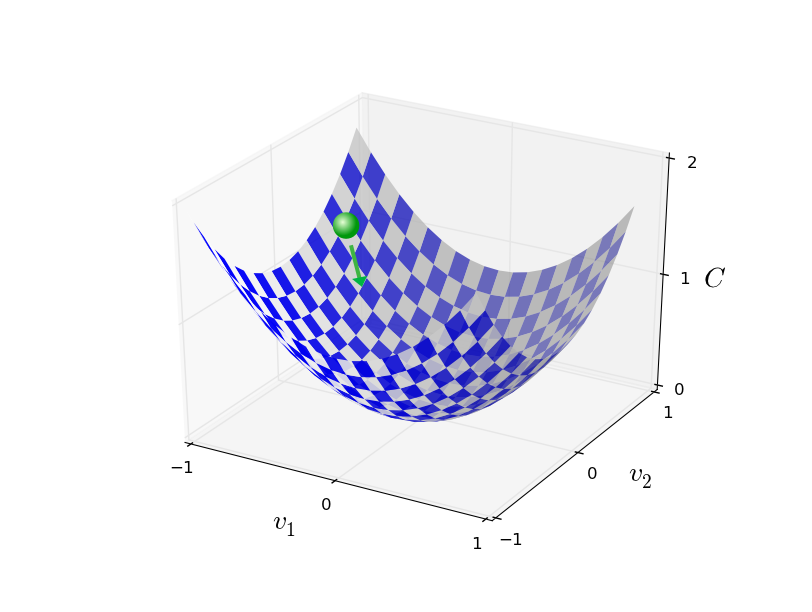

Randomly select $m$ training examples $X_j$ and compute the gradient of the loss function ($L$).  Update weights and biases with a given _learning rate_  $\eta$.
$$ w_k' = w_k-\frac{\eta}{m}\sum_j^m 
\frac{\partial L_{X_j}}{\partial w_k}$$
$$b_l' = b_l-\frac{\eta}{m}
  \sum_j^m \frac{\partial L_{X_j}}{\partial b_l}
$$

Common loss functions: logistic, hinge, euclidean

# Loss Functions

<center><img src="./files/lossfuncs.png"></center>



# Deep Learning

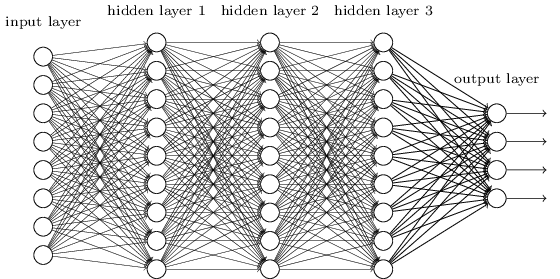

A deep network is not more powerful (recall can approximate any function with a single layer), but may be more concise - can approximate some functions with many fewer nodes.

## Training neural networks comprises of the following steps
 - **A forward pass, making predictions on training data.**
 - **A loss function measures the error of the model’s predictions during that forward pass.**
 - **Backpropagation of error, or a backward pass, to calculate the partial derivatives of the loss function.**
 - **Gradient descent, to update model weights.**

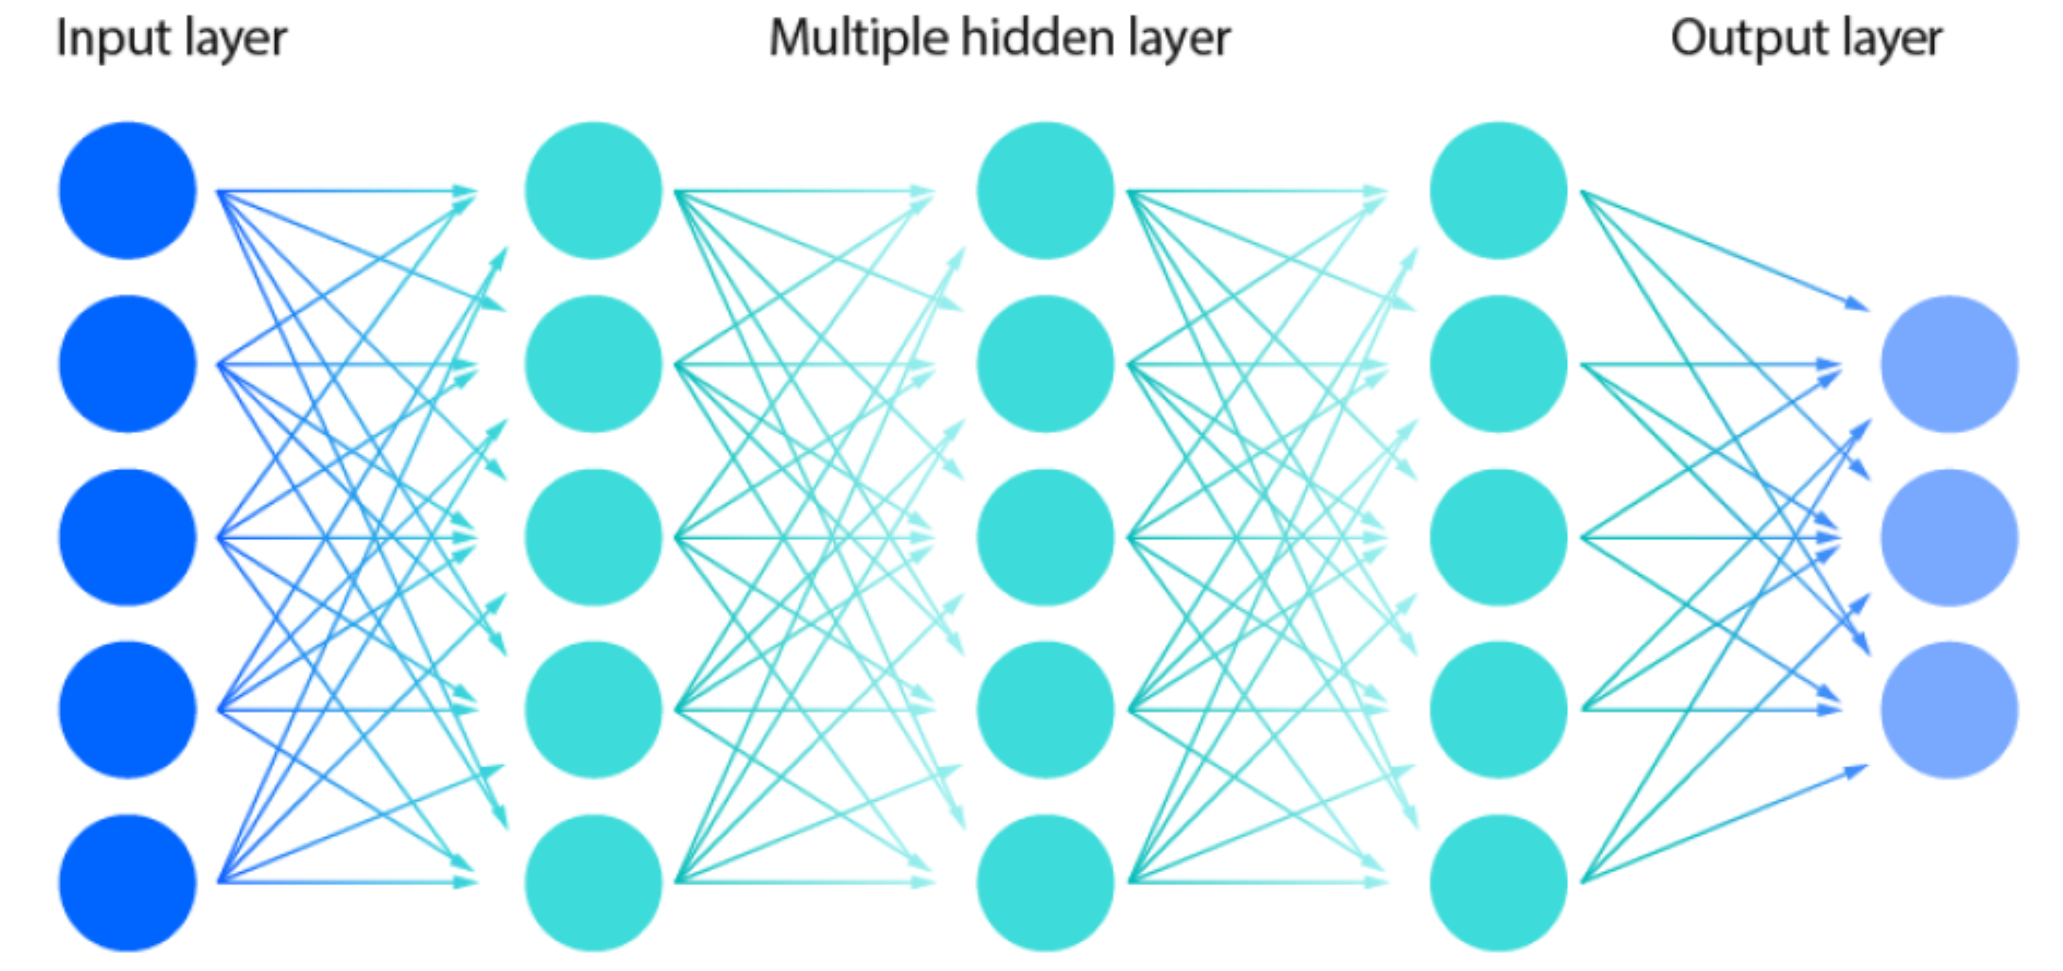

# Convolutional Layers

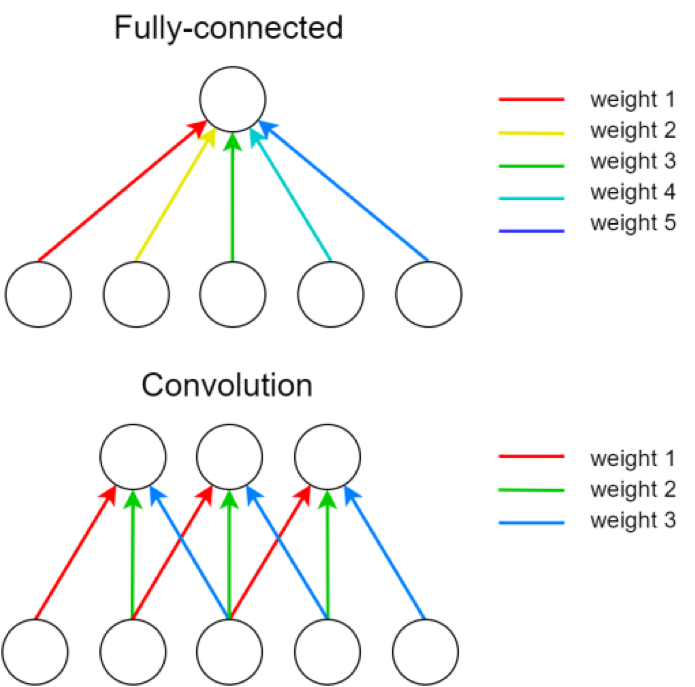

A single kernel is applied across the input.  For each output feature map there is a single set of weights.

# Convolutional Neural Nets

**Winners of ImageNet challenge**

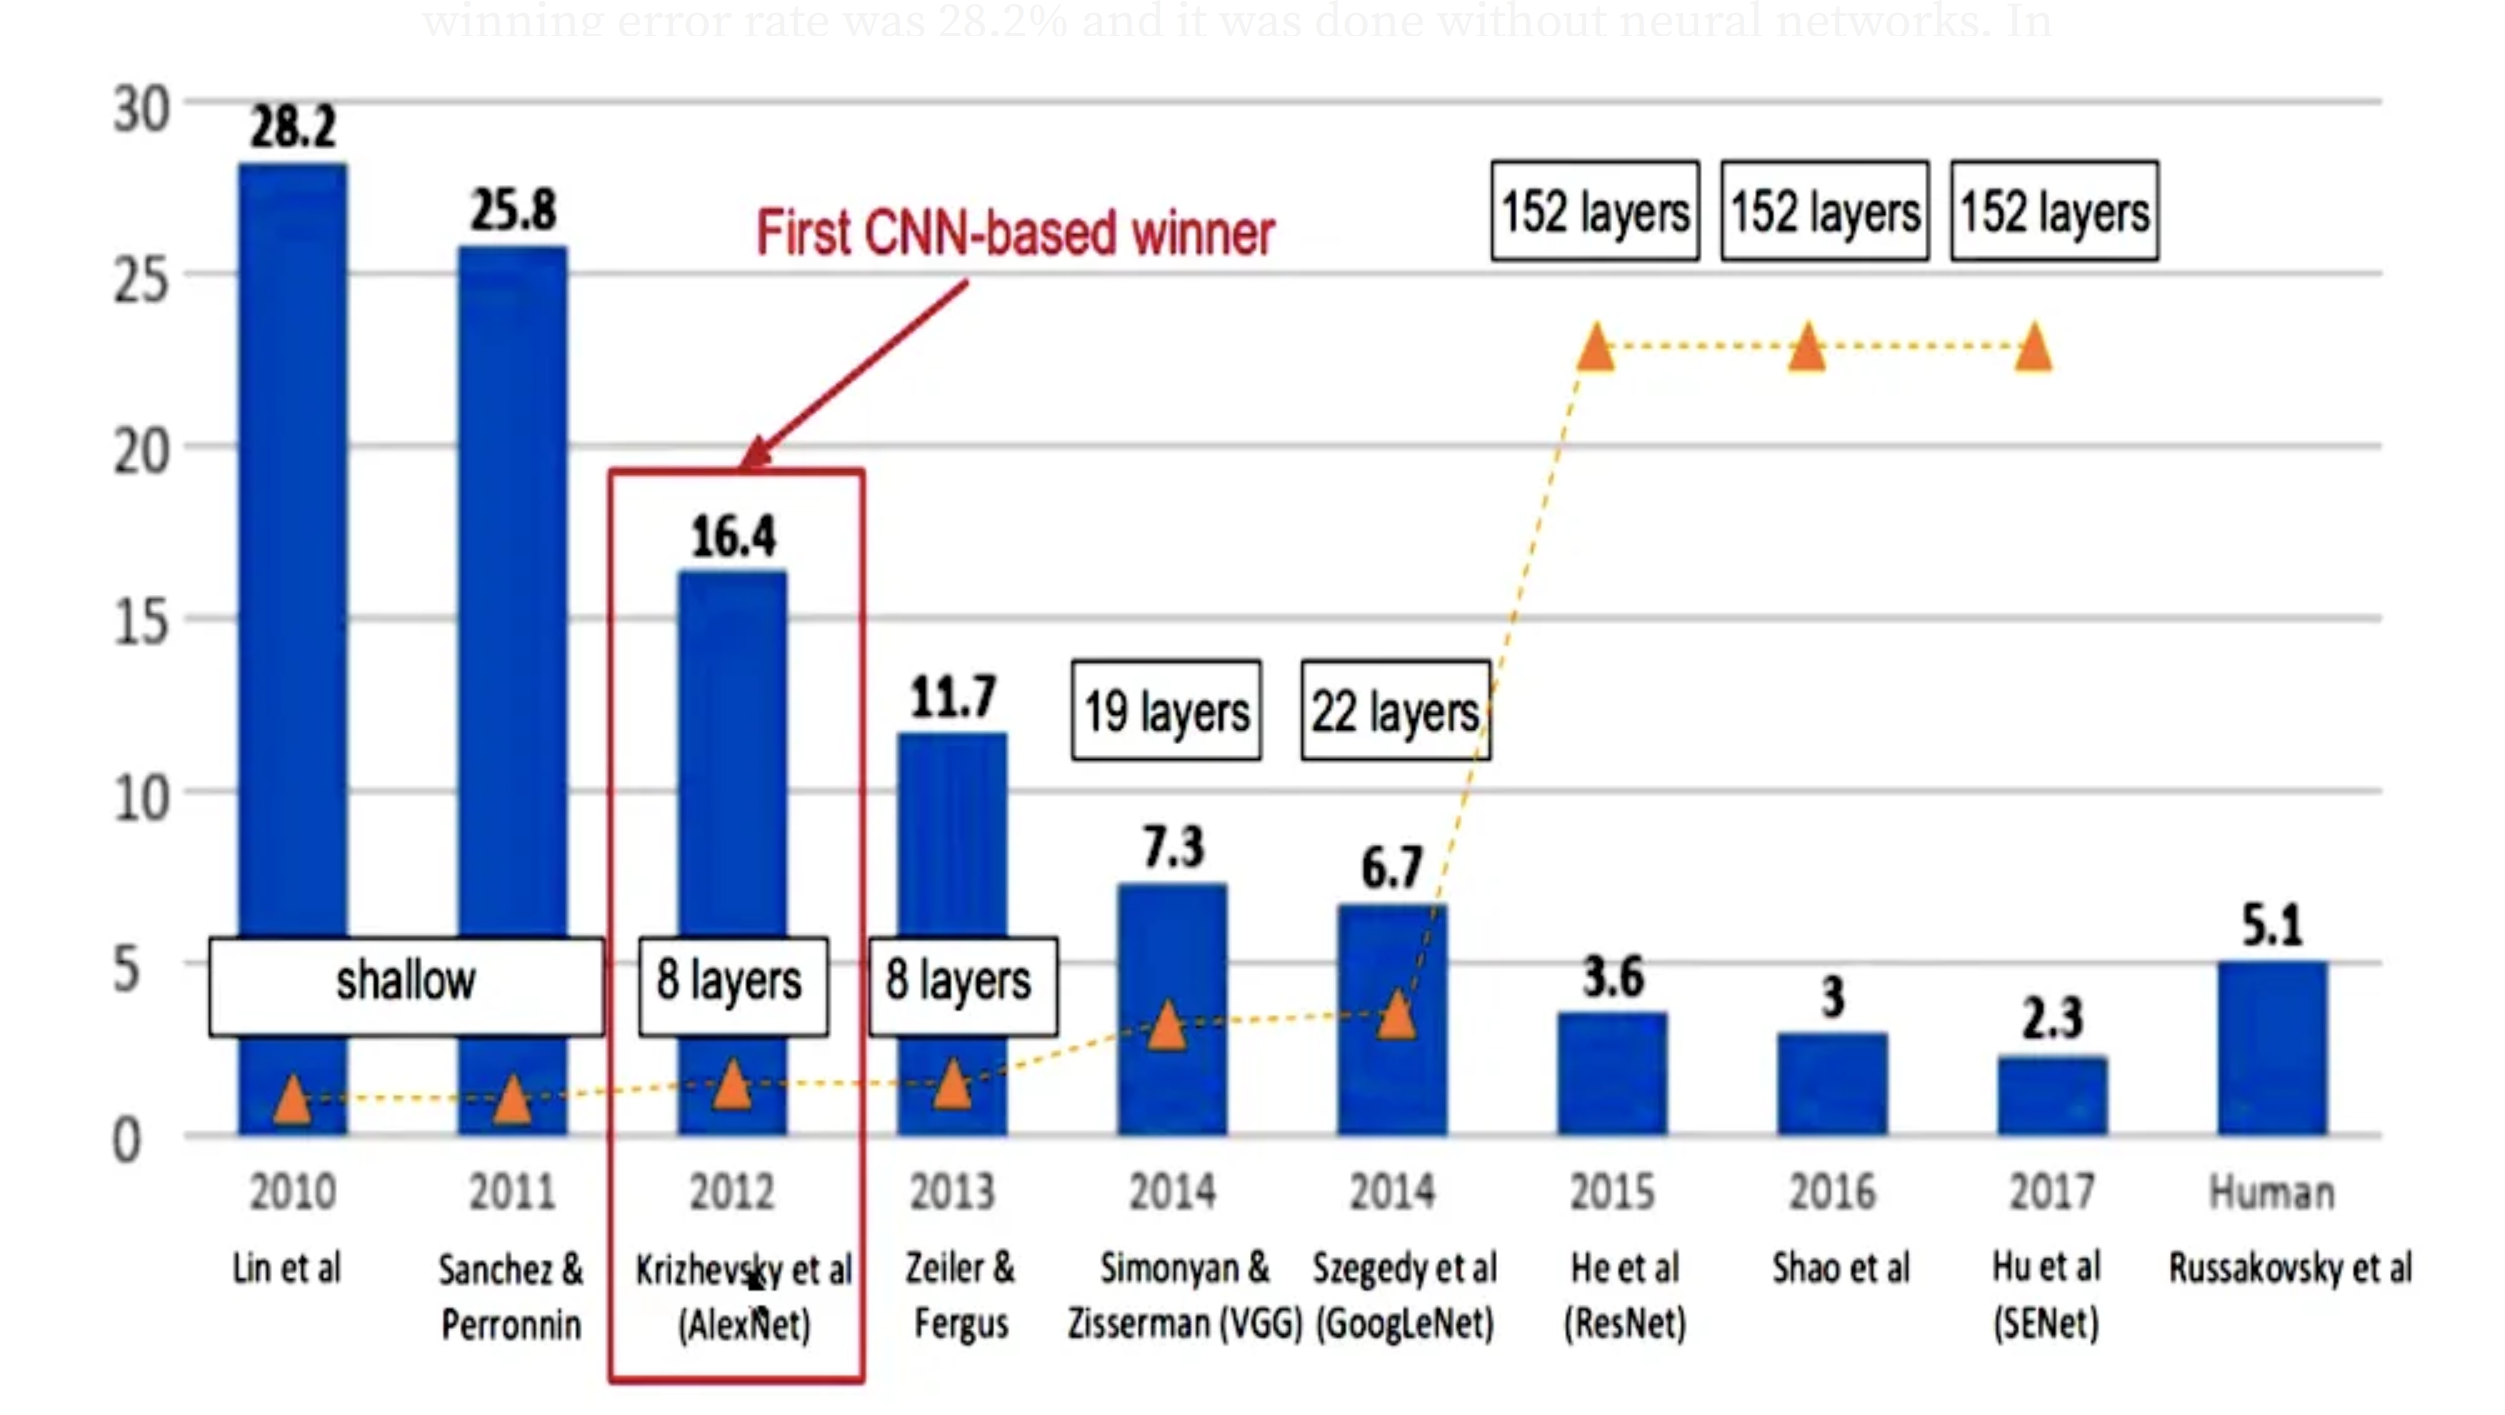

# Convolution Filters

A filter applies a *convolution kernel* to an image.  

The kernel is represented by an $n$x$n$ matrix where the target pixel is in the center.  

The output of the filter is the sum of the products of the matrix elements with the corresponding pixels.

Examples from [Wikipedia](https://en.wikipedia.org/wiki/Kernel_(image_processing)):

<table style="border: 0px solid black; text-align=center">
<tr><td><img src="https://upload.wikimedia.org/math/7/a/d/7ad9f1c26f76bc1ee55fdf0ef8c6197a.png"></td>
<td>
<img src="https://upload.wikimedia.org/math/3/0/c/30c42f667a353a5f0fbe92b0c4f2eee1.png">
</td>
<td>
<img src="https://upload.wikimedia.org/math/7/d/d/7ddb57480ef9fa57e2d1c2b3ffecb291.png">
</td>
</tr>
<tr><td>Identity</td><td>Blur</td><td>Edge Detection</td>
</table>

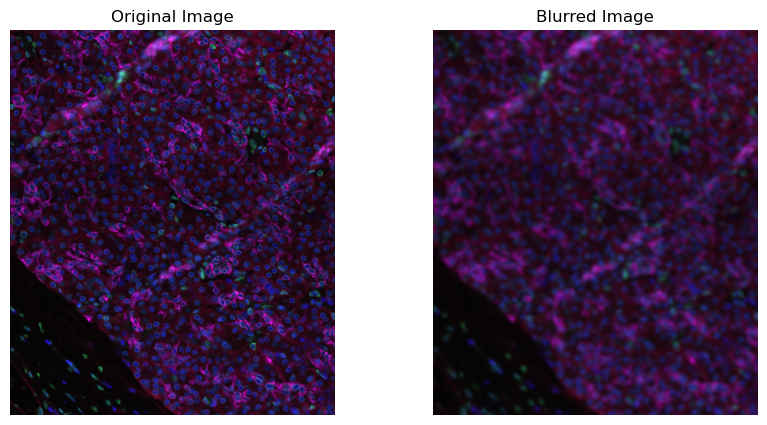

In [1]:
from skimage import io, img_as_float
from skimage.filters import gaussian, laplace
import matplotlib.pyplot as plt
import numpy as np

# Load the biological image (replace 'path_to_image.jpg' with your image path)
image_path = './files/bioimage.png'
original_image = img_as_float(io.imread(image_path))  # Convert image to float for processing

# Apply Gaussian blur using skimage
blurred_image = gaussian(original_image, sigma=2, channel_axis=2)

# Display the original and blurred images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

# Blurred Image
plt.subplot(1, 2, 2)
plt.title('Blurred Image')
plt.imshow(blurred_image)
plt.axis('off')

plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


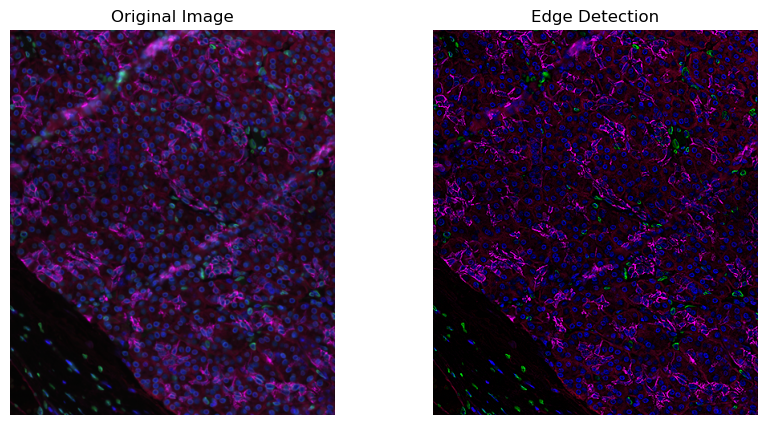

In [2]:
# Apply laplacian using skimage
blurred_image = laplace(original_image, ksize=3)

# Display the original and blurred images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

# Blurred Image
plt.subplot(1, 2, 2)
plt.title('Edge Detection')
plt.imshow(blurred_image)
plt.axis('off')

plt.show()

# Feature Maps

We can think of a kernel as identifying a *feature* in an image and the resulting image as a feature map that has high values (white) where the feature is present and low values (black) elsewhere.

*Feature maps retain the **spatial relationship** between features present in the original image.*


# Convolutional Layers

For images, each pixel is an input feature.  Each hidden layer is a set of feature maps.

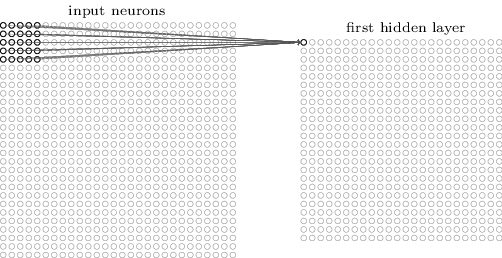

Consider an input image with 100 pixels.  In a classic neural network, we hook these pixels up to a hidden layer with 10 nodes.  In a CNN, we hook these pixels up to a convolutional layer with a 3x3 kernel and 10 output feature maps.

### Question: "Which network has more parameters to learn?",
- Classic
- CNN